# Imports

In [1]:
import numpy as np
import cupy as cp
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.ops import box_iou, box_convert
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.notebook import tqdm

### Set seed

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Load dataset

In [3]:
class OxfordPetsWithBBox:
    """Custom dataset class that extracts bounding boxes from segmentation masks."""

    def __init__(self, root, split, image_size=(64, 64), download=True):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=download
        )
        self.image_size = image_size
        self.image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.NEAREST),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image_tensor = self.image_transform(image)
        mask_resized = self.mask_transform(mask)
        mask_array = np.array(mask_resized)
        return image_tensor, mask_array

def get_bounding_box_from_mask(mask):

    binary_mask = (mask == 1) | (mask == 3)
    coords = np.where(binary_mask)

    if len(coords[0]) == 0:
        return None

    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()

    return x_min, y_min, x_max, y_max

def normalize_bbox(mask, image_size=(64, 64)):

    bbox = get_bounding_box_from_mask(mask)

    if bbox is None:
        return np.array([0.5, 0.5, 0.1, 0.1], dtype=np.float32)

    x_min, y_min, x_max, y_max = bbox
    img_h, img_w = image_size

    x_center = (x_min + x_max) / 2.0 / img_w
    y_center = (y_min + y_max) / 2.0 / img_h
    width = (x_max - x_min) / img_w
    height = (y_max - y_min) / img_h
    x_center = np.clip(x_center, 0, 1)
    y_center = np.clip(y_center, 0, 1)
    width = np.clip(width, 0.01, 1)
    height = np.clip(height, 0.01, 1)

    return np.array([x_center, y_center, width, height], dtype=np.float32)

In [4]:

print("="*60)
print("TASK 1: Load the Oxford-IIIT Pets Dataset")
print("="*60)

IMAGE_SIZE = (192, 192)

print("\nDownloading and loading trainval split...")
trainval_dataset = OxfordPetsWithBBox(
    root='./data',
    split='trainval',
    image_size=IMAGE_SIZE,
    download=True
)

print("Downloading and loading test split...")
test_dataset = OxfordPetsWithBBox(
    root='./data',
    split='test',
    image_size=IMAGE_SIZE,
    download=True
)

print(f"\n{'='*60}")
print(f"Dataset loaded successfully!")
print(f"{'='*60}")
print(f"Trainval size: {len(trainval_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Image size: {IMAGE_SIZE}")

TASK 1: Load the Oxford-IIIT Pets Dataset


Dataset loaded successfully!
Trainval size: 3680
Test size: 3669
Image size: (192, 192)


In [5]:
print("TASK 2: Augmentation and DataLoader Creation")
print("="*60)

print("\nExtracting images and bounding boxes from trainval set...")

trainval_images = []
trainval_targets = []
test_images = []
test_targets = []

for img, mask in tqdm(trainval_dataset, desc="Processing trainval"):
    trainval_images.append(img.numpy())
    trainval_targets.append(normalize_bbox(mask, IMAGE_SIZE))

trainval_images = np.array(trainval_images)
trainval_targets = np.array(trainval_targets)

print(f"\nTrainval images shape: {trainval_images.shape}")
print(f"Trainval targets shape: {trainval_targets.shape}\n")

# Create test dataset
for img, mask in tqdm(test_dataset, desc="Processing test"):
    test_images.append(img.numpy())
    test_targets.append(normalize_bbox(mask, IMAGE_SIZE))

trainval_images = np.array(trainval_images)
trainval_targets = np.array(trainval_targets)
test_images = np.array(test_images)
test_targets = np.array(test_targets)

# Split into train (80%) and validation (20%)
print("\nSplitting trainval into train (80%) and validation (20%)...")
train_size = int(0.8 * len(trainval_images))

indices = np.random.permutation(len(trainval_images))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_images = trainval_images[train_indices]
train_targets = trainval_targets[train_indices]
val_images = trainval_images[val_indices]
val_targets = trainval_targets[val_indices]

print(f"\n{'='*60}")
print(f"Data Split Summary:")
print(f"{'='*60}")
print(f"Train set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")
print(f"Test set size: {len(test_images)}")
print(f"Train images shape: {train_images.shape}")
print(f"Train targets shape: {train_targets.shape}")
print(f"Val images shape: {val_images.shape}")
print(f"Val targets shape: {val_targets.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test targets shape: {test_targets.shape}")

TASK 2: Augmentation and DataLoader Creation

Extracting images and bounding boxes from trainval set...


Processing trainval:   0%|          | 0/3680 [00:00<?, ?it/s]


Trainval images shape: (3680, 3, 192, 192)
Trainval targets shape: (3680, 4)



Processing test:   0%|          | 0/3669 [00:00<?, ?it/s]


Splitting trainval into train (80%) and validation (20%)...

Data Split Summary:
Train set size: 2944
Validation set size: 736
Test set size: 3669
Train images shape: (2944, 3, 192, 192)
Train targets shape: (2944, 4)
Val images shape: (736, 3, 192, 192)
Val targets shape: (736, 4)
Test images shape: (3669, 3, 192, 192)
Test targets shape: (3669, 4)


## Visualise the dataset

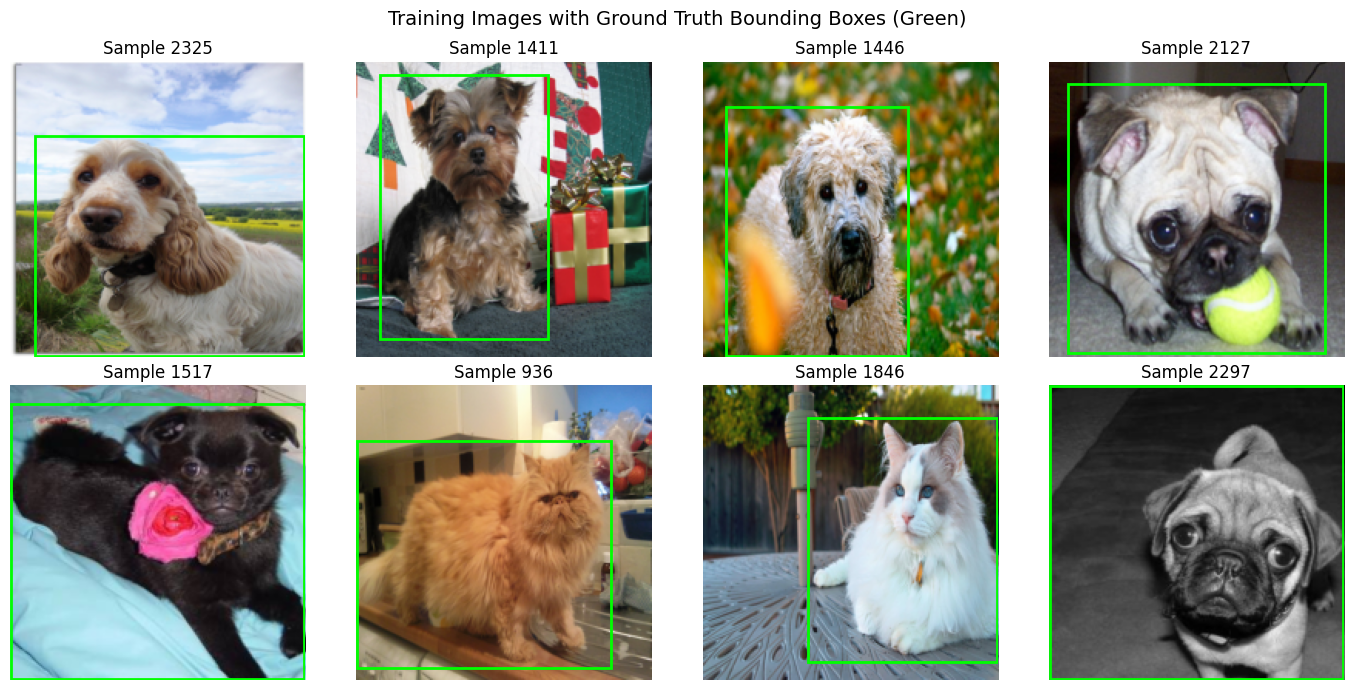


Bounding box format: [x_center, y_center, width, height] (normalized 0-1)
Sample bbox: [0.5104167  0.5286458  0.35416666 0.8802083 ]


In [6]:

def plot_image_with_bbox(img, bbox, ax, title=""):
    """Plot image with bounding box overlay."""
    if len(img.shape) == 3 and img.shape[0] == 3:
        img = img.transpose(1, 2, 0)  # CHW -> HWC

    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

    h, w = IMAGE_SIZE
    x_center, y_center, bw, bh = bbox
    x_min = (x_center - bw / 2) * w
    y_min = (y_center - bh / 2) * h
    width = bw * w
    height = bh * h

    rect = patches.Rectangle(
        (x_min, y_min), width, height,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

sample_indices = np.random.choice(len(train_images), 8, replace=False)

for i, idx in enumerate(sample_indices):
    plot_image_with_bbox(train_images[idx], train_targets[idx], axes[i], f"Sample {idx}")

plt.suptitle('Training Images with Ground Truth Bounding Boxes (Green)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nBounding box format: [x_center, y_center, width, height] (normalized 0-1)")
print(f"Sample bbox: {train_targets[0]}")

# Numpy Model

# DISCALIMER
I have used cupy instead of numpy to speed up the processing. This was done as a last resort as even vectorized numpy scripts were taking substantial amount of time. The logic remains exactly same as cupy is a drop in replacement for numpy.

## Helper methods

In [7]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        self.weights = cp.random.randn(out_channels, in_channels, kernel_size, kernel_size).astype(cp.float32) * cp.sqrt(2.0 / (in_channels * kernel_size * kernel_size), dtype=cp.float32)
        self.bias = cp.zeros(out_channels, dtype=cp.float32)

    def _im2col(self, x, kernel_size, stride):
        batch_size, channels, height, width = x.shape
        out_height = (height - kernel_size) // stride + 1
        out_width = (width - kernel_size) // stride + 1

        b_stride, c_stride, h_stride, w_stride = x.strides
        
        strided = cp.lib.stride_tricks.as_strided(
            x,
            shape=(batch_size, channels, out_height, out_width, kernel_size, kernel_size),
            strides=(b_stride, c_stride, h_stride * stride, w_stride * stride, h_stride, w_stride)
        )
        return strided.transpose(1, 4, 5, 0, 2, 3).reshape(channels * kernel_size * kernel_size, batch_size * out_height * out_width)

    def _col2im(self, cols, x_shape, kernel_size, stride):
        batch_size, channels, height, width = x_shape
        out_height = (height - kernel_size) // stride + 1
        out_width = (width - kernel_size) // stride + 1

        cols = cols.reshape(channels, kernel_size, kernel_size, batch_size, out_height, out_width)
        cols = cols.transpose(3, 0, 1, 2, 4, 5)
        x = cp.zeros(x_shape, dtype=cols.dtype)

        for i in range(kernel_size):
            for j in range(kernel_size):
                x[:, :, i:i+out_height*stride:stride, j:j+out_width*stride:stride] += cols[:, :, i, j, :, :]
        return x

    def forward(self, x):
        batch_size, in_channels, height, width = x.shape
        if self.padding > 0:
            padded_x = cp.pad(x, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        else:
            padded_x = x

        self.x_shape = padded_x.shape
        out_height = (self.x_shape[2] - self.kernel_size) // self.stride + 1
        out_width = (self.x_shape[3] - self.kernel_size) // self.stride + 1

        self.x_col = cp.ascontiguousarray(self._im2col(padded_x, self.kernel_size, self.stride))
        w_col = self.weights.reshape(self.out_channels, -1)

        out = cp.dot(w_col, self.x_col)
        out = out.reshape(self.out_channels, batch_size, out_height, out_width).transpose(1, 0, 2, 3)
        out = out + self.bias.reshape(1, -1, 1, 1)
        return out

    def backward(self, grad_output, learning_rate):
        batch_size, out_channels, out_height, out_width = grad_output.shape
        
        grad_output_col = grad_output.transpose(1, 0, 2, 3).reshape(out_channels, -1)
        w_col = self.weights.reshape(self.out_channels, -1)
        
        # Calculate gradients
        grad_weights = cp.dot(grad_output_col, self.x_col.T).reshape(self.weights.shape)
        grad_bias = cp.sum(grad_output, axis=(0, 2, 3))
        
        grad_x_col = cp.dot(w_col.T, grad_output_col)
        grad_input = self._col2im(grad_x_col, self.x_shape, self.kernel_size, self.stride)

        self.weights -= learning_rate * grad_weights
        self.bias -= learning_rate * grad_bias
        
        if self.padding > 0:
            return grad_input[:, :, self.padding:-self.padding, self.padding:-self.padding]
        return grad_input

class ReLU:
    def forward(self, x):
        self.x = x
        return cp.maximum(0, x)

    def backward(self, grad_output, learning_rate):
        return grad_output * (self.x > 0)

class MaxPool2D:
    def __init__(self, pool_size=2, stride=2, padding=0):
        self.pool_size = pool_size
        self.stride = stride
        self.padding = padding

    def _im2col(self, x, pool_size, stride):
        batch_size, channels, height, width = x.shape
        out_height = (height - pool_size) // stride + 1
        out_width = (width - pool_size) // stride + 1

        b_stride, c_stride, h_stride, w_stride = x.strides
        
        strided = cp.lib.stride_tricks.as_strided(
            x,
            shape=(batch_size, channels, out_height, out_width, pool_size, pool_size),
            strides=(b_stride, c_stride, h_stride * stride, w_stride * stride, h_stride, w_stride)
        )
        return strided.transpose(0, 1, 4, 5, 2, 3).reshape(batch_size, channels, pool_size * pool_size, out_height * out_width)

    def forward(self, x):
        batch_size, in_channels, height, width = x.shape
        if self.padding > 0:
            padded_x = cp.pad(x, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        else:
            padded_x = x

        self.x_shape = padded_x.shape
        out_height = (self.x_shape[2] - self.pool_size) // self.stride + 1
        out_width = (self.x_shape[3] - self.pool_size) // self.stride + 1

        self.x_col = self._im2col(padded_x, self.pool_size, self.stride)
        self.max_idx = cp.argmax(self.x_col, axis=2)
        out = cp.max(self.x_col, axis=2)
        
        return out.reshape(batch_size, in_channels, out_height, out_width)

    def backward(self, grad_output, learning_rate):
        batch_size, in_channels, out_height, out_width = grad_output.shape
        
        grad_output_col = grad_output.reshape(batch_size, in_channels, -1)
        grad_x_col = cp.zeros_like(self.x_col)
        
        batch_idx = cp.arange(batch_size)[:, None, None]
        channel_idx = cp.arange(in_channels)[None, :, None]
        spatial_idx = cp.arange(out_height * out_width)[None, None, :]
        
        grad_x_col[batch_idx, channel_idx, self.max_idx, spatial_idx] = grad_output_col
        
        x_shape_col2im = self.x_shape
        out_height = (x_shape_col2im[2] - self.pool_size) // self.stride + 1
        out_width = (x_shape_col2im[3] - self.pool_size) // self.stride + 1

        cols = grad_x_col.reshape(batch_size, in_channels, self.pool_size, self.pool_size, out_height, out_width)
        grad_input = cp.zeros(x_shape_col2im, dtype=grad_output.dtype)

        for i in range(self.pool_size):
            for j in range(self.pool_size):
                grad_input[:, :, i:i+out_height*self.stride:self.stride, j:j+out_width*self.stride:self.stride] += cols[:, :, i, j, :, :]

        if self.padding > 0:
            return grad_input[:, :, self.padding:-self.padding, self.padding:-self.padding]
        return grad_input

class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, grad_output, learning_rate):
        return grad_output.reshape(self.shape)

class Dense:
    def __init__(self, in_features, out_features):
        self.weights = cp.random.randn(in_features, out_features).astype(cp.float32) * cp.sqrt(2.0 / in_features, dtype=cp.float32)
        self.bias = cp.zeros(out_features, dtype=cp.float32)

    def forward(self, x):
        self.x = x
        return cp.dot(x.astype(cp.float32), self.weights) + self.bias

    def backward(self, grad_output, learning_rate):
        grad_weights = cp.dot(self.x.T.astype(cp.float32), grad_output.astype(cp.float32))
        grad_bias = cp.sum(grad_output, axis=0)
        grad_input = cp.dot(grad_output.astype(cp.float32), self.weights.T.astype(cp.float32))

        self.weights -= learning_rate * grad_weights
        self.bias -= learning_rate * grad_bias
        return grad_input

class BatchNorm2D:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.gamma = cp.ones((1, num_features, 1, 1), dtype=cp.float32)
        self.beta = cp.zeros((1, num_features, 1, 1), dtype=cp.float32)
        self.running_mean = cp.zeros((1, num_features, 1, 1), dtype=cp.float32)
        self.running_var = cp.ones((1, num_features, 1, 1), dtype=cp.float32)
        self.training = True

    def forward(self, x):
        if self.training:
            self.mean = cp.mean(x, axis=(0, 2, 3), keepdims=True)
            self.var = cp.var(x, axis=(0, 2, 3), keepdims=True)
            self.x_norm = (x - self.mean) / cp.sqrt(self.var + self.eps)
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.var
        else:
            self.x_norm = (x - self.running_mean) / cp.sqrt(self.running_var + self.eps)
        return self.gamma * self.x_norm + self.beta

    def backward(self, grad_output, learning_rate):
        N = grad_output.shape[0] * grad_output.shape[2] * grad_output.shape[3]
        grad_gamma = cp.sum(grad_output * self.x_norm, axis=(0, 2, 3), keepdims=True)
        grad_beta = cp.sum(grad_output, axis=(0, 2, 3), keepdims=True)

        dx_norm = grad_output * self.gamma
        dvar = cp.sum(dx_norm * self.x_norm * -0.5 / (self.var + self.eps), axis=(0, 2, 3), keepdims=True)
        dmean = cp.sum(dx_norm * -1.0 / cp.sqrt(self.var + self.eps), axis=(0, 2, 3), keepdims=True) + dvar * cp.mean(-2.0 * self.x_norm * cp.sqrt(self.var + self.eps), axis=(0, 2, 3), keepdims=True)
        
        grad_input = (dx_norm / cp.sqrt(self.var + self.eps)) + (dvar * 2.0 * self.x_norm * cp.sqrt(self.var + self.eps) / N) + (dmean / N)

        self.gamma -= learning_rate * grad_gamma
        self.beta -= learning_rate * grad_beta
        return grad_input
        
class GlobalAvgPool2D:
    def forward(self, x):
        self.x = x
        return cp.mean(x, axis=(2, 3), keepdims=True)

    def backward(self, grad_output, learning_rate):
        batch, channels, h, w = self.x.shape
        return grad_output * cp.ones_like(self.x) / (h * w)

class Sigmoid:
    def forward(self, x):
        self.out = 1.0 / (1.0 + cp.exp(-x))
        return self.out

    def backward(self, grad_output, learning_rate):
        return grad_output * self.out * (1.0 - self.out)

class Dropout:
    def __init__(self, p=0.3):
        self.p = p
        self.training = True

    def forward(self, x):
        if self.training:
            self.mask = (cp.random.rand(*x.shape) > self.p) / (1.0 - self.p)
            return x * self.mask
        return x

    def backward(self, grad_output, learning_rate):
        return grad_output * self.mask

class MSELoss:
    def forward(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        return cp.mean((y_pred - y_true) ** 2)

    def backward(self):
        return 2.0 * (self.y_pred - self.y_true) / self.y_pred.shape[0]

## CNN Model

In [ ]:
class CNN:
    def __init__(self):
        self.layers = [
            Conv2D(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3),
            ReLU(),
            MaxPool2D(pool_size=3, stride=2, padding=1),

            Conv2D(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            BatchNorm2D(128),
            ReLU(),

            Conv2D(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1),
            BatchNorm2D(256),
            ReLU(),

            Conv2D(in_channels=256, out_channels=512, kernel_size=3, stride=2, padding=1),
            BatchNorm2D(512),
            ReLU(),

            Conv2D(in_channels=512, out_channels=512, kernel_size=3, stride=2, padding=1),
            BatchNorm2D(512),
            ReLU(),

            GlobalAvgPool2D(),
            Flatten(),

            Dense(512, 256),
            ReLU(),
            Dropout(0.3),
            
            Dense(256, 128),
            ReLU(),
            
            Dense(128, 4),
            Sigmoid()
        ]
        self.loss_fn = MSELoss()

    def set_mode(self, training=True):
        for layer in self.layers:
            if hasattr(layer, 'training'):
                layer.training = training

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad_output, learning_rate):
        for layer in reversed(self.layers):
            grad_output = layer.backward(grad_output, learning_rate)

    def train(self, x_train, y_train, x_val, y_val, epochs, learning_rate, batch_size=32):
        train_losses = []
        val_losses = []

        epoch_pbar = tqdm(range(epochs), desc="Epochs (Numpy/Cupy)")

        num_train_batches = int(np.ceil(len(x_train) / batch_size))
        num_val_batches = int(np.ceil(len(x_val) / batch_size))

        for epoch in epoch_pbar:
            self.set_mode(training=True)
            epoch_train_loss = 0

            # Shuffle data
            indices = np.random.permutation(len(x_train))
            x_train_shuffled = x_train[indices]
            y_train_shuffled = y_train[indices]

            train_pbar = tqdm(range(num_train_batches), leave=False)
            for i in train_pbar:
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, len(x_train))
                
                batch_x = cp.array(x_train_shuffled[start_idx:end_idx])
                batch_y = cp.array(y_train_shuffled[start_idx:end_idx])

                output = self.forward(batch_x)
                loss = self.loss_fn.forward(output, batch_y)
                epoch_train_loss += loss.item() * (end_idx - start_idx)

                grad_output = self.loss_fn.backward()
                self.backward(grad_output, learning_rate)
                
                # Free memory
                del batch_x, batch_y, output, loss, grad_output
                cp.get_default_memory_pool().free_all_blocks()

            avg_train_loss = epoch_train_loss / len(x_train)
            train_losses.append(avg_train_loss)

            self.set_mode(training=False)
            epoch_val_loss = 0
            
            for i in range(num_val_batches):
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, len(x_val))
                
                batch_x = cp.array(x_val[start_idx:end_idx])
                batch_y = cp.array(y_val[start_idx:end_idx])

                output = self.forward(batch_x)
                loss = self.loss_fn.forward(output, batch_y)
                epoch_val_loss += loss.item() * (end_idx - start_idx)
                
                del batch_x, batch_y, output, loss
                cp.get_default_memory_pool().free_all_blocks()

            avg_val_loss = epoch_val_loss / len(x_val)
            val_losses.append(avg_val_loss)

            epoch_pbar.set_description(f"Epoch {epoch}")
            epoch_pbar.set_postfix({"Train Loss": f"{avg_train_loss:.4f}", "Val Loss": f"{avg_val_loss:.4f}"})

        return train_losses, val_losses

    def predict(self, x_test, batch_size=32):
        self.set_mode(training=False)
        predictions = []
        num_batches = int(np.ceil(len(x_test) / batch_size))
        
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, len(x_test))
            batch_x = cp.array(x_test[start_idx:end_idx])
            output = self.forward(batch_x)
            predictions.append(cp.asnumpy(output))
            del batch_x, output
            cp.get_default_memory_pool().free_all_blocks()

        return np.vstack(predictions)

    def save_model(self, file_path="numpy_model.npz"):
        weights = {}
        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'weights'):
                weights[f"layer_{idx}_weights"] = layer.weights
                weights[f"layer_{idx}_bias"] = layer.bias
            if hasattr(layer, 'gamma'):
                weights[f"layer_{idx}_gamma"] = layer.gamma
                weights[f"layer_{idx}_beta"] = layer.beta
                weights[f"layer_{idx}_running_mean"] = layer.running_mean
                weights[f"layer_{idx}_running_var"] = layer.running_var
        cp.savez(file_path, **weights)
        print(f"Model saved to {file_path}")

    def load_model(self, file_path="numpy_model.npz"):
        weights = cp.load(file_path)
        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'weights'):
                layer.weights = weights[f"layer_{idx}_weights"]
                layer.bias = weights[f"layer_{idx}_bias"]
            if hasattr(layer, 'gamma'):
                layer.gamma = weights[f"layer_{idx}_gamma"]
                layer.beta = weights[f"layer_{idx}_beta"]
                layer.running_mean = weights[f"layer_{idx}_running_mean"]
                layer.running_var = weights[f"layer_{idx}_running_var"]
        print(f"Model loaded from {file_path}")

## Training

In [ ]:
np_X_train = train_images.reshape(-1, 3, 192, 192).astype(np.float32)
np_y_train = train_targets.astype(np.float32)

np_X_val = val_images.reshape(-1, 3, 192, 192).astype(np.float32)
np_y_val = val_targets.astype(np.float32)

np_X_test = test_images.reshape(-1, 3, 192, 192).astype(np.float32)
np_y_test = test_targets.astype(np.float32)


In [ ]:
cnn = CNN()
# Lesser amount of epochs and batch size to reduce training time and memory usage
train_losses_cp, val_losses_cp = cnn.train(np_X_train, np_y_train, np_X_val, np_y_val, epochs=50, learning_rate=0.001, batch_size=16)


Epochs (Numpy/Cupy):   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

...

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

In [11]:
# Save Numpy model
cnn.save_model("scratch_cnn_model.npz")

Model saved to scratch_cnn_model.npz


## Plot

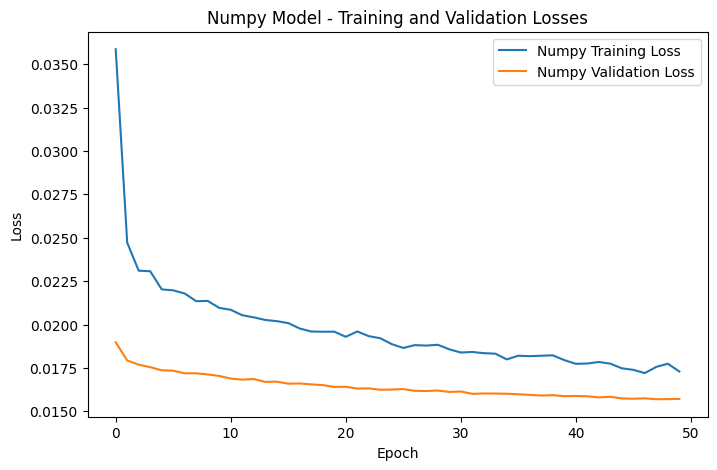

In [12]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_cp, label='Numpy Training Loss')
plt.plot(val_losses_cp, label='Numpy Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Numpy Model - Training and Validation Losses')
plt.legend()
plt.show()

## Evaluation

In [ ]:
preds_cp = cnn.predict(np_X_test, batch_size=32)

numpy_iou_scores = []
preds_tensor = torch.tensor(preds_cp)
targets_tensor = torch.tensor(np_y_test)

# Convert from cxcywh to xyxy for box_iou
preds_xyxy = box_convert(preds_tensor, in_fmt='cxcywh', out_fmt='xyxy')
targets_xyxy = box_convert(targets_tensor, in_fmt='cxcywh', out_fmt='xyxy')

# box_iou computes pairwise IoU, returning an NxN matrix.
# Just need the diagonal elements.
iou_matrix = box_iou(preds_xyxy, targets_xyxy)
numpy_iou_batch = torch.diag(iou_matrix)

numpy_avg_iou = numpy_iou_batch.mean().item()
print(f"Scratch (Numpy/CuPy) Model Average IoU Score: {numpy_avg_iou:.4f}")

Scratch (Numpy/CuPy) Model Average IoU Score: 0.6497


# PyTorch Model

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class PyTorchCNN(nn.Module):
    def __init__(self):
        super(PyTorchCNN, self).__init__()
        
        # Input: 3 x 192 x 192 -> Output: 64 x 96 x 96
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3)
        self.relu1 = nn.ReLU()
        
        # Input: 64 x 96 x 96 -> Output: 64 x 48 x 48
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Output: 128 x 48 x 48
        self.conv_block1 = ConvBlock(64, 128, stride=1)
        
        # Output: 256 x 24 x 24
        self.conv_block2 = ConvBlock(128, 256, stride=2)
        
        # Output: 512 x 12 x 12
        self.conv_block3 = ConvBlock(256, 512, stride=2)
        
        # Output: 512 x 6 x 6
        self.conv_block4 = ConvBlock(512, 512, stride=2)
        
        # Output: 512 x 1 x 1
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(in_features=512, out_features=256)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.relu_fc2 = nn.ReLU()
        
        self.fc3 = nn.Linear(in_features=128, out_features=4)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool(x)
        
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        
        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu_fc2(x)
        
        x = self.fc3(x)
        x = self.sigmoid(x)
        
        return x

In [ ]:
from torchsummary import summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_to_analyse = PyTorchCNN().to(device)

summary(model_to_analyse, (3, 192, 192))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 96, 96]          9,472
├─ReLU: 1-2                              [-1, 64, 96, 96]          --
├─MaxPool2d: 1-3                         [-1, 64, 48, 48]          --
├─ConvBlock: 1-4                         [-1, 128, 48, 48]         --
|    └─Conv2d: 2-1                       [-1, 128, 48, 48]         73,856
|    └─BatchNorm2d: 2-2                  [-1, 128, 48, 48]         256
|    └─ReLU: 2-3                         [-1, 128, 48, 48]         --
├─ConvBlock: 1-5                         [-1, 256, 24, 24]         --
|    └─Conv2d: 2-4                       [-1, 256, 24, 24]         295,168
|    └─BatchNorm2d: 2-5                  [-1, 256, 24, 24]         512
|    └─ReLU: 2-6                         [-1, 256, 24, 24]         --
├─ConvBlock: 1-6                         [-1, 512, 12, 12]         --
|    └─Conv2d: 2-7                       [-1, 512, 12, 12]         1,18

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 96, 96]          9,472
├─ReLU: 1-2                              [-1, 64, 96, 96]          --
├─MaxPool2d: 1-3                         [-1, 64, 48, 48]          --
├─ConvBlock: 1-4                         [-1, 128, 48, 48]         --
|    └─Conv2d: 2-1                       [-1, 128, 48, 48]         73,856
|    └─BatchNorm2d: 2-2                  [-1, 128, 48, 48]         256
|    └─ReLU: 2-3                         [-1, 128, 48, 48]         --
├─ConvBlock: 1-5                         [-1, 256, 24, 24]         --
|    └─Conv2d: 2-4                       [-1, 256, 24, 24]         295,168
|    └─BatchNorm2d: 2-5                  [-1, 256, 24, 24]         512
|    └─ReLU: 2-6                         [-1, 256, 24, 24]         --
├─ConvBlock: 1-6                         [-1, 512, 12, 12]         --
|    └─Conv2d: 2-7                       [-1, 512, 12, 12]         1,18

## Training

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Convert dataset to PyTorch tensors
X_train = torch.from_numpy(train_images.reshape(-1, 3, 192, 192).astype(np.float32))
X_val = torch.from_numpy(val_images.reshape(-1, 3, 192, 192).astype(np.float32))
X_test = torch.from_numpy(test_images.reshape(-1, 3, 192, 192).astype(np.float32))

y_train = torch.from_numpy(train_targets).float()
y_val = torch.from_numpy(val_targets).float()
y_test = torch.from_numpy(test_targets).float()

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
#Initialize Model, Optimizer and Loss Function
model = PyTorchCNN()
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [18]:
train_losses = []
val_losses = []
epochs = 150

epoch_pbar = tqdm(range(epochs), desc="Epochs")

for epoch in epoch_pbar:
    model.train()
    epoch_train_loss = 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)
    for batch_x, batch_y in train_pbar:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_x.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False)
        for batch_x, batch_y in val_pbar:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            epoch_val_loss += loss.item() * batch_x.size(0)
            
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    epoch_pbar.set_description(f"Epoch {epoch}")
    epoch_pbar.set_postfix({"Train Loss": f"{avg_train_loss:.4f}", "Val Loss": f"{avg_val_loss:.4f}"})


Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 0 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 0 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 147 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 148 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 148 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 149 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 149 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

## Plot

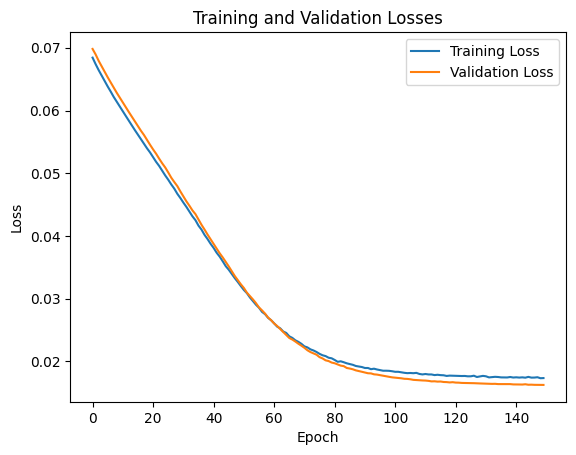

In [ ]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

## Evaluation

In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in tqdm(test_loader, desc="Evaluating on Test Set"):
        output = model(batch_x)
        all_preds.append(output.cpu())
        all_targets.append(batch_y.cpu())

# Calculate IoU scores
iou_scores = []
for preds, targets in zip(all_preds, all_targets):
    preds_xyxy = box_convert(preds, in_fmt='cxcywh', out_fmt='xyxy')
    targets_xyxy = box_convert(targets, in_fmt='cxcywh', out_fmt='xyxy')
    
    iou_matrix = box_iou(preds_xyxy, targets_xyxy)
    iou_batch = torch.diag(iou_matrix)
    
    iou_scores.extend(iou_batch.numpy())

# Calculate average IoU score
avg_iou = sum(iou_scores) / len(iou_scores)
print(f"Average IoU Score: {avg_iou:.4f}")

Evaluating on Test Set:   0%|          | 0/115 [00:00<?, ?it/s]

Average IoU Score: 0.6386


### Save model

In [ ]:
# Create checkpoints & load for PyTorch
torch.save(model.state_dict(), "pytorch_cnn_model.pth")
print("PyTorch model saved to pytorch_cnn_model.pth")

# loaded_model = PyTorchCNN()
# loaded_model.load_state_dict(torch.load("pytorch_cnn_model.pth"))
# loaded_model.eval()

PyTorch model saved to pytorch_cnn_model.pth


# Comparison

In [22]:
print("="*60)
print("IoU Score Comparisons")
print("="*60)
print(f"Scratch (CuPy) Model Average IoU: {numpy_avg_iou:.4f}")
print(f"PyTorch Model Average IoU:          {avg_iou:.4f}")
print("="*60)

IoU Score Comparisons
Scratch (CuPy) Model Average IoU: 0.6497
PyTorch Model Average IoU:          0.6386


## Output samples

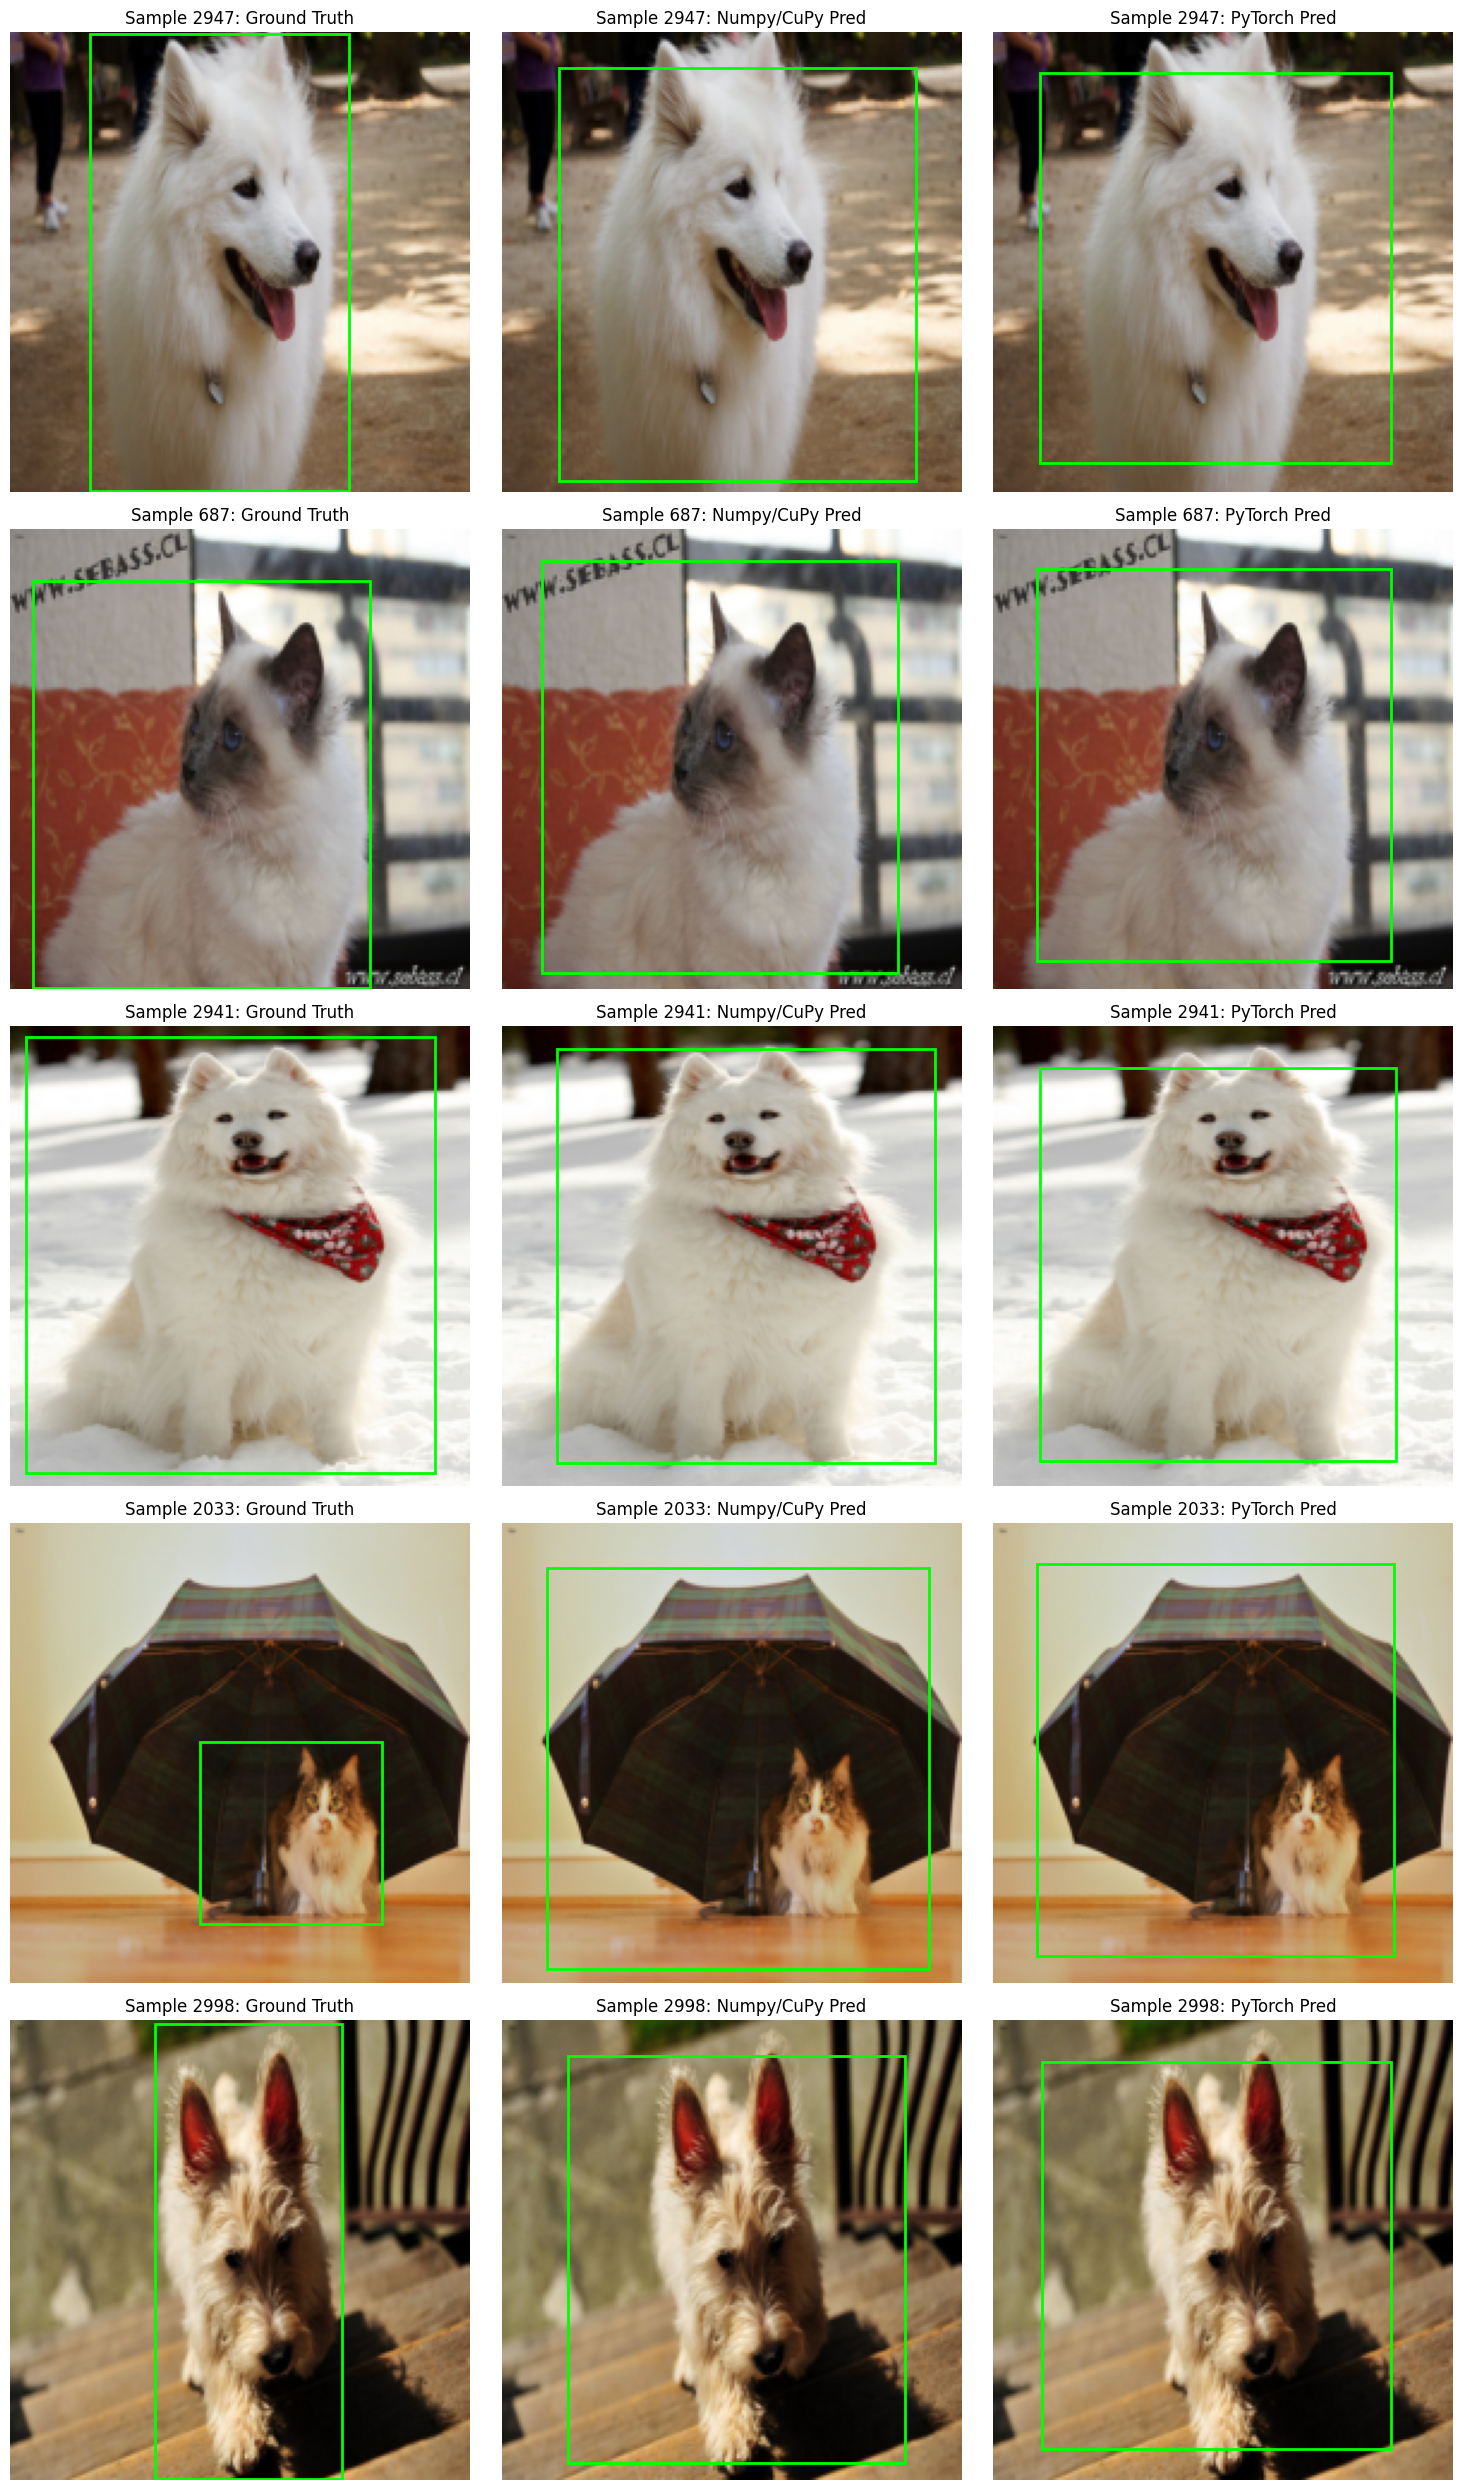

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
sample_indices = np.random.choice(len(test_images), 5, replace=False)

for i, idx in enumerate(sample_indices):
    img_np = test_images[idx]
    
    # Ground Truth
    gt_bbox = test_targets[idx]
    
    # Numpy Model Prediction
    input_cp = cp.array(img_np.reshape(1, 3, 192, 192).astype(np.float32))
    pred_numpy_bbox = cp.asnumpy(cnn.predict(input_cp)[0])
    
    # PyTorch Model Prediction
    input_pt = torch.tensor(img_np.reshape(1, 3, 192, 192).astype(np.float32))
    model.eval()
    with torch.no_grad():
        pred_pytorch_bbox = model(input_pt).numpy()[0]
        
    plot_image_with_bbox(img_np.copy(), gt_bbox, axes[i, 0], f"Sample {idx}: Ground Truth")
    plot_image_with_bbox(img_np.copy(), pred_numpy_bbox, axes[i, 1], f"Sample {idx}: Numpy/CuPy Pred")
    plot_image_with_bbox(img_np.copy(), pred_pytorch_bbox, axes[i, 2], f"Sample {idx}: PyTorch Pred")

plt.tight_layout()
plt.show()